In [7]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.exp(x)

def df_exact(x):
    return np.exp(x)

def d2f_exact(x):
    return np.exp(x)

def df_fwd(f, x, h):
    return (f(x + h) - f(x)) / h

def df_cnt(f, x, h):
    return (f(x + h) - f(x - h)) / (2 * h)

def d2f(f, x, h):
    return (f(x + h) - 2 * f(x) + f(x - h)) / (h ** 2)

x0 = 1.0

# step sizes
hs = np.array([0.2, 0.1, 0.05, 0.025])
#hs = np.array([0.1, 0.01, 0.001])
print(hs)

print(f"{'h':>10} | {'err_fwd':>12} | {'err_cnt':>12} | {'err_d2':>12}")
print("-" * 55)

errors_fwd = []
errors_cnt = []
errors_d2 = []

for h in hs:
    err_fwd = abs(df_fwd(f, x0, h) - df_exact(x0))
    err_cnt = abs(df_cnt(f, x0, h) - df_exact(x0))
    err_d2 = abs(d2f(f, x0, h) - d2f_exact(x0))

    errors_fwd.append(err_fwd)
    errors_cnt.append(err_cnt)
    errors_d2.append(err_d2)

    print(f"{h:10.2e} | {err_fwd:12.4e} | {err_cnt:12.4e} | {err_d2:12.4e}")


# estimate convergence order
def estimate_order(errors, hs):
    orders = []
    for i in range(1, len(errors)):
        order = np.log(errors[i] / errors[i-1]) / np.log(hs[i] / hs[i-1])
        orders.append(order)
    return orders


orders_fwd = estimate_order(errors_fwd, hs)
orders_cnt = estimate_order(errors_cnt, hs)
orders_d2 = estimate_order(errors_d2, hs)

print("\nEstimated orders:")
print(f"Forward difference  ~ {np.mean(orders_fwd):.2f}")
print(f"Centered difference ~ {np.mean(orders_cnt):.2f}")
print(f"Second derivative   ~ {np.mean(orders_d2):.2f}")


[0.2   0.1   0.05  0.025]
         h |      err_fwd |      err_cnt |       err_d2
-------------------------------------------------------
  2.00e-01 |   2.9089e-01 |   1.8158e-02 |   9.0730e-03
  1.00e-01 |   1.4056e-01 |   4.5327e-03 |   2.2660e-03
  5.00e-02 |   6.9104e-02 |   1.1328e-03 |   5.6636e-04
  2.50e-02 |   3.4263e-02 |   2.8316e-04 |   1.4158e-04

Estimated orders:
Forward difference  ~ 1.03
Centered difference ~ 2.00
Second derivative   ~ 2.00


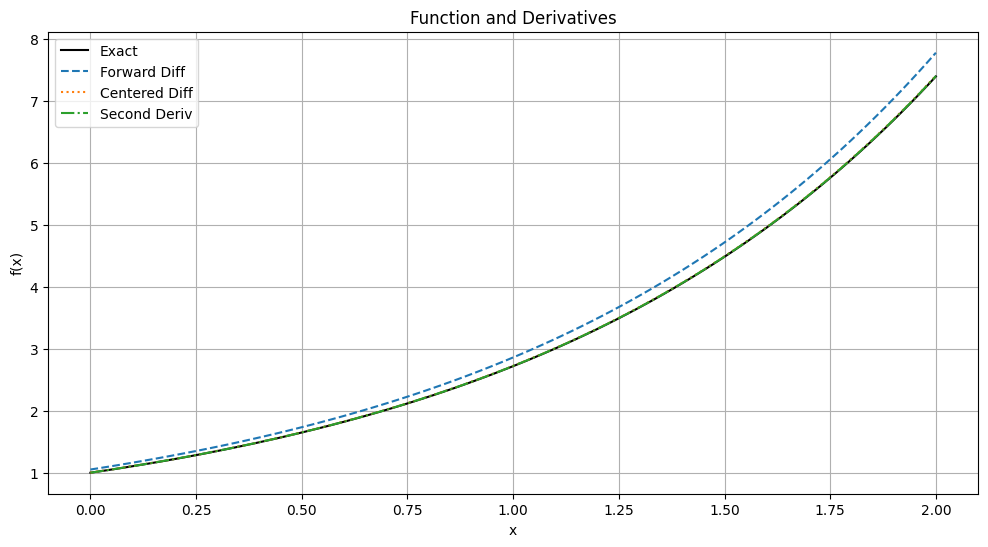

In [ ]:
plt.figure(figsize=(12, 6))
x_vals = np.linspace(0, 2, 100)
plt.plot(x_vals, f(x_vals), label='Exact', color='black')
plt.plot(x_vals, df_fwd(f, x_vals, 0.1), label='Forward Diff', linestyle='dashed')
plt.plot(x_vals, df_cnt(f, x_vals, 0.1), label='Centered Diff', linestyle='dotted')
plt.plot(x_vals, d2f(f, x_vals, 0.1), label='Second Deriv', linestyle='dashdot')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Function and Derivatives')
plt.legend()
plt.grid()
plt.show()
